# 09 — Evaluación confirmatoria temporal 2025

Las configuraciones fueron congeladas tras la validación 2024. Este notebook reentrena con 2020–2024 y evalúa una sola vez en 2025. No realiza selección, ajuste de hiperparámetros ni cambios de variables.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, auc, balanced_accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'salidas_modelado' / 'bases_finales_riesgo'
OUTPUT_DIR = BASE_DIR / 'salidas_modelado' / 'evaluacion_confirmatoria_2025'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET = 'NIVEL_DE_RIESGO_VICTIMA'
LABELS, LABEL_NAMES = ['1', '2', '3'], ['Leve', 'Moderado', 'Severo']
RANDOM_SEED, N_ARBOLES, N_ITERACIONES_BOOSTING = 20260827, 200, 300
EJECUTAR_EVALUACION_FINAL = True  # Cambiar a True solo para la evaluación confirmatoria.

FEATURES_INICIAL = ['VINCULO_AGRESOR_VICTIMA', 'PRIMERA_VEZ_AGREDE', 'ESTADO_AGRESOR_U_A', 'EDAD_VICTIMA', 'NIVEL_EDUCATIVO_VICTIMA', 'AREA_RESIDENCIA_DOMICILIO', 'REDES_FAM_SOC', 'SEXO_AGRESOR', 'SEXO_VICTIMA']
print('Salida:', OUTPUT_DIR)

Salida: C:\Users\jcollazos\CODEX\salidas_modelado\evaluacion_confirmatoria_2025


In [2]:
def cargar(escenario, corte):
    sufijos = {'train': 'train_2020_2023', 'validacion': 'validacion_2024', 'prueba': 'prueba_2025'}
    tabla = pd.read_parquet(DATA_DIR / f'riesgo_{escenario}_{sufijos[corte]}.parquet')
    tabla['EDAD_VICTIMA'] = pd.to_numeric(tabla['EDAD_VICTIMA'], errors='raise')
    return tabla

def preprocesador_arboles(features):
    cat = [c for c in features if c != 'EDAD_VICTIMA']
    return ColumnTransformer([('edad', 'passthrough', ['EDAD_VICTIMA']), ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat)])

def metricas(y, pred, nombre):
    p, r, f, s = precision_recall_fscore_support(y, pred, labels=LABELS, zero_division=0)
    filas = [{'modelo': nombre, 'metrica': 'accuracy', 'clase': 'global', 'valor': accuracy_score(y,pred)}, {'modelo': nombre, 'metrica': 'balanced_accuracy', 'clase': 'global', 'valor': balanced_accuracy_score(y,pred)}, {'modelo': nombre, 'metrica': 'macro_f1', 'clase': 'global', 'valor': f1_score(y,pred,labels=LABELS,average='macro',zero_division=0)}]
    for clase, a, b, c, d in zip(LABEL_NAMES,p,r,f,s):
        filas += [{'modelo':nombre,'metrica':'precision','clase':clase,'valor':a},{'modelo':nombre,'metrica':'recall','clase':clase,'valor':b},{'modelo':nombre,'metrica':'f1','clase':clase,'valor':c},{'modelo':nombre,'metrica':'soporte','clase':clase,'valor':d}]
    return filas


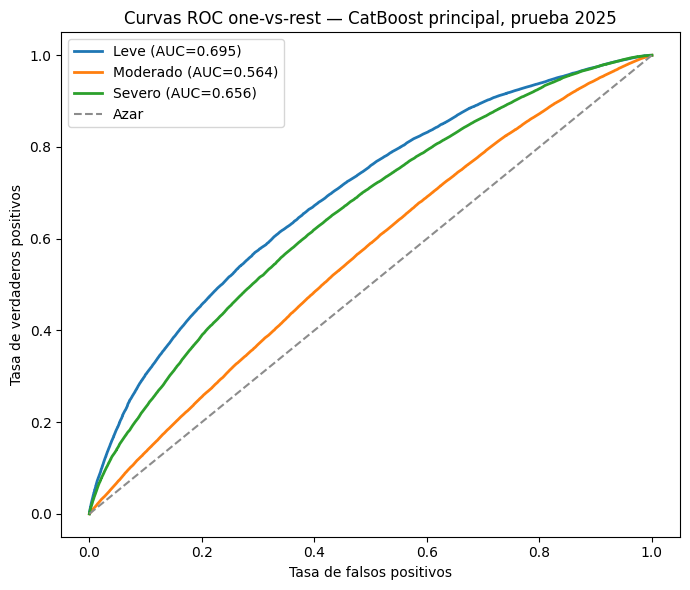

,modelo,metrica,clase,valor
15,complementario_retrospectivo_random_forest,accuracy,global,0.440667
16,complementario_retrospectivo_random_forest,balanced_accuracy,global,0.519210
28,complementario_retrospectivo_random_forest,f1,Severo,0.525956
17,complementario_retrospectivo_random_forest,macro_f1,global,0.442538
26,complementario_retrospectivo_random_forest,precision,Severo,0.457828
27,complementario_retrospectivo_random_forest,recall,Severo,0.617904
0,principal_inicial_catboost_parsimonioso,accuracy,global,0.436993
1,principal_inicial_catboost_parsimonioso,balanced_accuracy,global,0.465869
13,principal_inicial_catboost_parsimonioso,f1,Severo,0.471583
2,principal_inicial_catboost_parsimonioso,macro_f1,global,0.432821


In [3]:
if EJECUTAR_EVALUACION_FINAL:
    resultados = []
    # Principal prospectivo congelado: CatBoost parsimonioso.
    inicial_train = pd.concat([cargar('inicial','train'), cargar('inicial','validacion')], ignore_index=True)
    inicial_test = cargar('inicial','prueba')
    cat_cols = [c for c in FEATURES_INICIAL if c != 'EDAD_VICTIMA']
    X_train = inicial_train[FEATURES_INICIAL].copy(); X_test = inicial_test[FEATURES_INICIAL].copy()
    for c in cat_cols: X_train[c], X_test[c] = X_train[c].astype(str), X_test[c].astype(str)
    cat = CatBoostClassifier(loss_function='MultiClass', iterations=N_ITERACIONES_BOOSTING, learning_rate=0.05, depth=6, auto_class_weights='Balanced', random_seed=RANDOM_SEED, thread_count=-1, verbose=False, allow_writing_files=False)
    cat.fit(X_train, inicial_train[TARGET].astype(int), cat_features=cat_cols)
    pred = np.asarray(cat.predict(X_test)).reshape(-1).astype(str)
    prob = cat.predict_proba(X_test)
    y_test = inicial_test[TARGET].astype('string')
    resultados += metricas(y_test, pred, 'principal_inicial_catboost_parsimonioso')
    cm_principal = pd.DataFrame(confusion_matrix(y_test, pred, labels=LABELS), index=LABEL_NAMES, columns=LABEL_NAMES)
    cm_principal.index.name, cm_principal.columns.name = 'real', 'predicho'
    cm_principal.to_csv(OUTPUT_DIR / 'matriz_principal_inicial_catboost_parsimonioso.csv', encoding='utf-8-sig')
    y_bin = label_binarize(y_test, classes=LABELS)
    roc_filas = []
    plt.figure(figsize=(7, 6))
    for idx, clase in enumerate(LABEL_NAMES):
        fpr, tpr, umbrales = roc_curve(y_bin[:, idx], prob[:, idx])
        auc_clase = auc(fpr, tpr)
        roc_filas.extend({'clase': clase, 'fpr': x, 'tpr': y, 'umbral': u, 'auc': auc_clase} for x, y, u in zip(fpr, tpr, umbrales))
        plt.plot(fpr, tpr, linewidth=2, label=f'{clase} (AUC={auc_clase:.3f})')
    pd.DataFrame(roc_filas).to_csv(OUTPUT_DIR / 'curvas_roc_ovr_catboost_2025.csv', index=False, encoding='utf-8-sig')
    plt.plot([0, 1], [0, 1], '--', color='0.55', label='Azar')
    plt.xlabel('Tasa de falsos positivos'); plt.ylabel('Tasa de verdaderos positivos')
    plt.title('Curvas ROC one-vs-rest — CatBoost principal, prueba 2025')
    plt.legend(); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'curvas_roc_ovr_catboost_2025.png', dpi=200, bbox_inches='tight')
    plt.show()
    # Complementario retrospectivo y sensibilidad, ambos congelados.
    retro_train = pd.concat([cargar('retrospectiva','train'), cargar('retrospectiva','validacion')], ignore_index=True)
    retro_test = cargar('retrospectiva','prueba')
    excluir = {TARGET, 'nivel_riesgo_etiqueta', 'anio_ingreso'}; features_retro = [c for c in retro_train if c not in excluir]
    for nombre, arbol in [('complementario_retrospectivo_random_forest', RandomForestClassifier(n_estimators=N_ARBOLES,min_samples_leaf=5,max_features='sqrt',class_weight='balanced_subsample',n_jobs=-1,random_state=RANDOM_SEED)), ('sensibilidad_retrospectiva_extra_trees', ExtraTreesClassifier(n_estimators=N_ARBOLES,min_samples_leaf=5,max_features='sqrt',class_weight='balanced',n_jobs=-1,random_state=RANDOM_SEED))]:
        modelo = Pipeline([('pre', preprocesador_arboles(features_retro)), ('modelo', arbol)])
        modelo.fit(retro_train[features_retro], retro_train[TARGET].astype('string'))
        pred = modelo.predict(retro_test[features_retro])
        resultados += metricas(retro_test[TARGET].astype('string'), pred, nombre)
        cm = pd.DataFrame(confusion_matrix(retro_test[TARGET].astype('string'), pred, labels=LABELS), index=LABEL_NAMES, columns=LABEL_NAMES)
        cm.to_csv(OUTPUT_DIR / f'matriz_{nombre}.csv', encoding='utf-8-sig')
    salida = pd.DataFrame(resultados); salida.to_csv(OUTPUT_DIR / 'metricas_confirmatorias_2025.csv', index=False, encoding='utf-8-sig')
    display(salida.query("metrica in ['accuracy','balanced_accuracy','macro_f1'] or (clase == 'Severo' and metrica in ['precision','recall','f1'])").sort_values(['modelo','metrica','clase']))
else:
    print('Evaluación no ejecutada. Cambie EJECUTAR_EVALUACION_FINAL a True.')